# 🧠 Insight Engine — Phase 3: The NLP Engine

> **Goal:** read ~18,000 credit-card complaints and automatically discover the **top problems**,
> ranked by how *common* and how *severe* they are — with no human reading them all.

**The pipeline (each step explained below):**
1. **Embed** — turn each complaint into a 'meaning-vector' (a point on a meaning-map).
2. **Cluster** — find the crowds of similar complaints; each crowd = a theme.
3. **Visualize** — see the crowds on a 2D map.
4. **Severity** — score how negative/serious each theme is.
5. **Rank** — priority = volume × severity → the 'fix-first' list.
6. **Name** — an AI gives each theme a clean, human name.

> The slow step (embedding) was computed once by `build_embeddings.py` and SAVED, so this
> notebook reloads it instantly. This is a professional pattern: cache expensive computations.

## 🟦 Cell 1 — Load the data and the saved meaning-vectors

**What this does:** loads the cleaned complaints and the pre-computed embeddings (384 numbers per
complaint). We reload the saved vectors instead of recomputing (which takes ~12 min).

**What we expect:** 18,000 complaints and an embeddings array of shape (18000, 384).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/sample_complaints.parquet")
emb = np.load("../data/sample_embeddings.npy")
print("Complaints:", len(df), "| Embeddings shape:", emb.shape)

Complaints: 18000 | Embeddings shape: (18000, 384)


**📖 Interpretation:** every complaint is now a point in 384-dimensional 'meaning space'.
Complaints with similar meaning have similar vectors — which is what lets us group them next.

## 🟦 Cell 2 — Cluster: find the crowds (themes)

**What this does:** KMeans splits the 18k points into 12 groups (themes). Each complaint gets a
theme number. KMeans is fast because the hard work (embedding) is already done.

**Why 12?** a sensible starting point for one product — enough to separate distinct problems
without fragmenting. (Easy to change; can be tuned with metrics like silhouette score.)

In [2]:
from sklearn.cluster import KMeans

N_THEMES = 12
km = KMeans(n_clusters=N_THEMES, random_state=42, n_init=10)
df["theme"] = km.fit_predict(emb)
print("Complaints per theme:")
print(df["theme"].value_counts().sort_index())

Complaints per theme:
theme
0     2334
1     1492
2     1073
3     2309
4     1725
5     1032
6     1579
7     2007
8      746
9     1220
10    1517
11     966
Name: count, dtype: int64


**📖 Interpretation:** the 18k complaints are now split into 12 themes of varying sizes. Next we
look at what each theme is about and how serious it is.

## 🟦 Cell 3 — Visualize the meaning-map

**What this does:** we can't see 384 dimensions, so PCA squashes them to 2 so we can plot every
complaint as a dot, colored by its theme.

**What we expect:** colored clouds — visual proof that similar complaints group together.

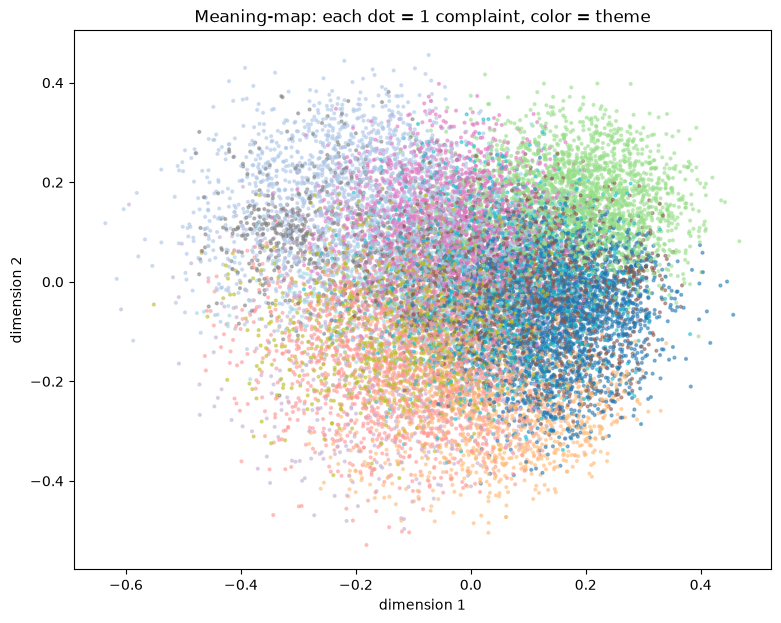

In [3]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(emb)
plt.figure(figsize=(9, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=df["theme"], cmap="tab20", s=4, alpha=0.5)
plt.title("Meaning-map: each dot = 1 complaint, color = theme")
plt.xlabel("dimension 1"); plt.ylabel("dimension 2")
plt.show()

**📖 Interpretation:** complaints form colored regions — the model really did place similar
complaints near each other. (PCA loses some detail, so regions overlap a bit; that's expected.)

## 🟦 Cell 4 — Severity: how bad is each complaint?

**What this does:** scores each complaint's negativity with VADER (a fast, lexicon-based
sentiment tool) and flags high-stakes words (fraud, stolen, identity...). We'll average these
per theme to get a severity score.

**Why:** a business fixes problems that are both common AND severe — not just common.

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
# negativity: 1 = very negative, 0 = positive.
comp = df["Consumer complaint narrative"].fillna("").apply(
    lambda t: analyzer.polarity_scores(t[:1000])["compound"])
df["negativity"] = (1 - comp) / 2

SEVERE = ["fraud", "unauthorized", "stolen", "steal", "scam", "theft",
          "identity", "threat", "lawsuit", "legal", "police", "victim"]
df["severe_flag"] = df["Consumer complaint narrative"].str.contains(
    "|".join(SEVERE), case=False, na=False).astype(int)
print("Average negativity:", round(df["negativity"].mean(), 3))
print("Share mentioning high-stakes words:", round(df["severe_flag"].mean() * 100, 1), "%")

Average negativity: 0.487
Share mentioning high-stakes words: 37.8 %


**📖 Interpretation:** complaints are quite negative on average (they're complaints!), and a
meaningful share mention serious issues like fraud/identity theft — which should raise priority.

## 🟦 Cell 5 — Rank themes by PRIORITY (volume × severity) + load AI names

**What this does:** aggregates severity per theme, computes priority = volume% × severity, and
merges the AI-generated names (created by `name_themes_llm.py`, saved in `theme_final.csv`).

**What we expect:** a ranked, human-named 'top problems' table — the business payoff.

In [5]:
# Aggregate severity per theme.
g = df.groupby("theme")
theme = pd.DataFrame({
    "count": g.size(),
    "severity": ((g["negativity"].mean() + g["severe_flag"].mean()) / 2).round(3),
})
theme["share_%"] = (theme["count"] / len(df) * 100).round(1)
theme["priority"] = (theme["share_%"] * theme["severity"]).round(2)

# Load the AI-generated names (from the LLM step).
final = pd.read_csv("../outputs/theme_final.csv")
final[["rank", "ai_name", "description", "priority"]].head(12)

,rank,ai_name,description,priority
0,1,Unauthorized Fraudulent Credit Card Charges,Customers experienced unauthorized or fraudule...,10.04
1,2,Merchant Purchase and Refund Disputes,"Customers face issues with unfair charges, unf...",6.86
2,3,Credit Reporting and Account Dispute,Consumers dispute inaccurate credit report inf...,4.36
3,4,Payment Processing and Account Management,"Issues related to payment processing holds, mi...",4.14
4,5,Credit Card Application and Account Restrictions,Customers experienced issues with merchant rej...,3.48
5,6,Fraudulent Accounts on Credit Reports,Failure to remove fraudulent or incorrectly re...,3.38
6,7,Unauthorized Charges and Account Fraud,"Customers report unauthorized card usage, frau...",2.99
7,8,Capital One Account and Payment Disputes,"Issues regarding unauthorized charges, failed ...",2.58
8,9,Unexpected Credit Card Account Closures,Banks abruptly closing long-standing credit ca...,2.20
9,10,Unexpected Fees and Promotional Charges,Customers were unfairly charged unexpected fee...,1.79


**📖 Interpretation:** this is the deliverable — the top credit-card problems, named in plain
English and ordered by priority. #1 (fraud) is both the most common and the most severe.

## 🟦 Cell 6 — The priority matrix (the headline chart)

**What this does:** plots each theme by volume (x) and severity (y). Top-right = fix first.

**What we expect:** fraud/dispute themes stand out in the high-volume, high-severity corner.

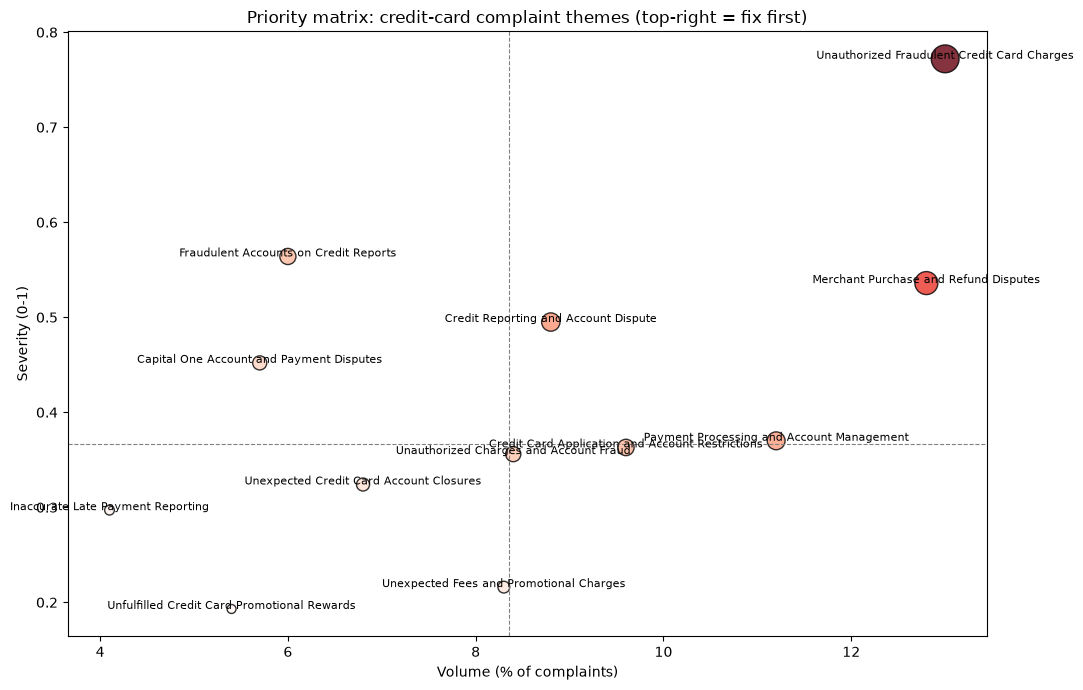

In [6]:
m = final.copy()
plt.figure(figsize=(11, 7))
plt.scatter(m["share_%"], m["severity"], s=m["priority"] * 40,
            c=m["priority"], cmap="Reds", edgecolors="black", alpha=0.8)
for _, r in m.iterrows():
    plt.annotate(str(r["ai_name"]), (r["share_%"], r["severity"]), fontsize=8, ha="center")
plt.axvline(m["share_%"].median(), color="grey", ls="--", lw=0.8)
plt.axhline(m["severity"].median(), color="grey", ls="--", lw=0.8)
plt.title("Priority matrix: credit-card complaint themes (top-right = fix first)")
plt.xlabel("Volume (% of complaints)"); plt.ylabel("Severity (0-1)")
plt.tight_layout(); plt.show()

**📖 Interpretation:** the bubbles in the top-right are the urgent, common problems — the ones a
bank should tackle first. This single chart turns 18k raw complaints into a clear action plan.

## 🟦 Cell 7 — Proof: real example complaints from the #1 theme

**What this does:** shows real complaints from the top-priority theme, so we can verify the theme
is real and correctly grouped (show, don't just tell).

**What we expect:** genuine fraud/unauthorized-charge complaints.

In [7]:
# Find the highest-priority theme id from the per-theme table we built in Cell 5,
# then show 3 real complaints from it.
top_theme_id = int(theme["priority"].idxmax())
print("Top-priority theme id:", top_theme_id)
examples = df[df["theme"] == top_theme_id]["Consumer complaint narrative"].head(3)
for i, e in enumerate(examples, 1):
    print(f"--- Example {i} ---")
    print(e[:300], "...\n")

Top-priority theme id: 0
--- Example 1 ---
On XX/XX/year> I was charged for {$220.00} by XXXX * XXXX. I used this Capital One card while traveling in XXXX as a safety measure. I wrote down every charge I made while there. Once I got home I checked my account to see the charge for {$220.00}. I did not make a purchase of this amount. All of my ...

--- Example 2 ---
Dell account compromised on XX/XX/XXXX, fraudulent laptop order # XXXX to be sent to XXXX XXXX at a fake address at XXXX XXXX XXXX, XXXX XXXX, XXXX. Requested to close Dell account with Dell associate from XXXX confirmed over the phone he has closed the account to prevent future fraud attempts. Also ...

--- Example 3 ---
I sent JP Morgan Chase absolute proof that I was in a different location the exact minute when my credit card was fraudulently charged for {$130.00} by an individual who obtained a " merchant '' account. Details below. I believe that Chase 's refusal to reverse the charges is evidence that the compa ...



**📖 Interpretation:** these are genuine complaints about unauthorized/fraudulent charges —
confirming the #1 theme is real and correctly grouped.

---
## ✅ Phase 3 summary
- Embedded 18k complaints → clustered into 12 themes → scored severity → ranked by priority →
  named each theme with an LLM.
- Output: a plain-English, prioritized 'top problems' list + a priority matrix a manager can act on.
- Artifacts saved in `outputs/`: theme_final.csv, theme_sizes.png, theme_map.png, priority_matrix.png.

**Next:** scale the pipeline to all ~112k complaints, then Phase 4 — the Streamlit upload app
(drop a complaints file, get this analysis back automatically).